# Robin Marte – Assignment 8
In this assignment, I use the Mushroom dataset from the UCI repository. I select a small subset of the data, rename the columns, convert the coded values into numeric values, and do some basic exploratory data analysis.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

## Loading the Data

I'll load the Mushroom dataset directly from the UCI repository.

In [2]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/mushroom/agaricus-lepiota.data"

mushrooms_raw = pd.read_csv(
    url,
    header=None,
    usecols=[0, 5, 22],
    names=["edible_poisonous", "odor", "habitat"],
    dtype=str
)

mushrooms_raw.head()

,edible_poisonous,odor,habitat
0,p,p,u
1,e,a,g
2,e,l,m
3,p,p,u
4,e,n,g


## Reviewing the Selected Columns

Before I convert anything, I'll look at the columns I selected and check the distributions of the original coded values.

In [3]:
class_labels = {"e": "edible", "p": "poisonous"}
odor_labels = {
    "a": "almond",
    "l": "anise",
    "c": "creosote",
    "y": "fishy",
    "f": "foul",
    "m": "musty",
    "n": "none",
    "p": "pungent",
    "s": "spicy"
}
habitat_labels = {
    "g": "grasses",
    "l": "leaves",
    "m": "meadows",
    "p": "paths",
    "u": "urban",
    "w": "waste",
    "d": "woods"
}

mushrooms_raw["edible_poisonous"].map(class_labels).value_counts()

,count
edible_poisonous,
edible,4208
poisonous,3916


In [4]:
mushrooms_raw["odor"].map(odor_labels).value_counts()

,count
odor,
none,3528
foul,2160
spicy,576
fishy,576
almond,400
anise,400
pungent,256
creosote,192
musty,36


In [5]:
mushrooms_raw["habitat"].map(habitat_labels).value_counts()

,count
habitat,
woods,3148
grasses,2148
paths,1144
leaves,832
urban,368
meadows,292
waste,192


## Converting the Codes to Numeric Values

I'll map each category to a number. This makes the data easier to use later with scikit-learn.

In [6]:
class_map = {"e": 0, "p": 1}
odor_map = {"a": 0, "l": 1, "c": 2, "y": 3, "f": 4, "m": 5, "n": 6, "p": 7, "s": 8}
habitat_map = {"g": 0, "l": 1, "m": 2, "p": 3, "u": 4, "w": 5, "d": 6}

mushrooms = pd.DataFrame({
    "edible_poisonous": mushrooms_raw["edible_poisonous"].map(class_map),
    "odor": mushrooms_raw["odor"].map(odor_map),
    "habitat": mushrooms_raw["habitat"].map(habitat_map)
})

mushrooms.head()

,edible_poisonous,odor,habitat
0,1,7,4
1,0,0,0
2,0,1,2
3,1,7,4
4,0,6,0


In [7]:
mushrooms.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   edible_poisonous  8124 non-null   int64
 1   odor              8124 non-null   int64
 2   habitat           8124 non-null   int64
dtypes: int64(3)
memory usage: 190.5 KB


## Scatterplot: Edible or Poisonous vs Odor

Now I'll compare the edible/poisonous label with odor to see whether odor looks like a useful predictor.

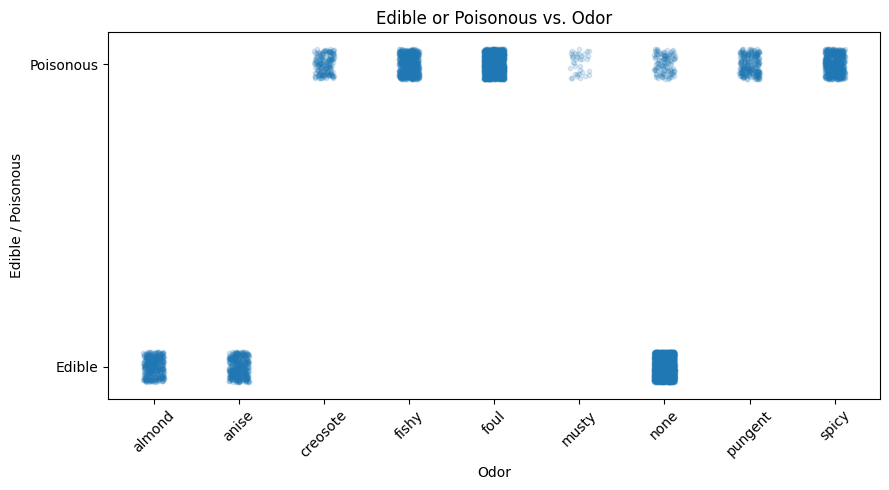

In [8]:
np.random.seed(0)

x = mushrooms["odor"] + np.random.uniform(-0.12, 0.12, size=len(mushrooms))
y = mushrooms["edible_poisonous"] + np.random.uniform(-0.05, 0.05, size=len(mushrooms))

plt.figure(figsize=(9, 5))
plt.scatter(x, y, alpha=0.15, s=10)
plt.yticks([0, 1], ["Edible", "Poisonous"])
plt.xticks(range(len(odor_labels)), list(odor_labels.values()), rotation=45)
plt.title("Edible or Poisonous vs. Odor")
plt.xlabel("Odor")
plt.ylabel("Edible / Poisonous")
plt.tight_layout()
plt.show()

## Scatterplot: Edible or Poisonous vs. Habitat

Next I'll compare the edible/poisonous label with habitat to see whether habitat looks useful too.

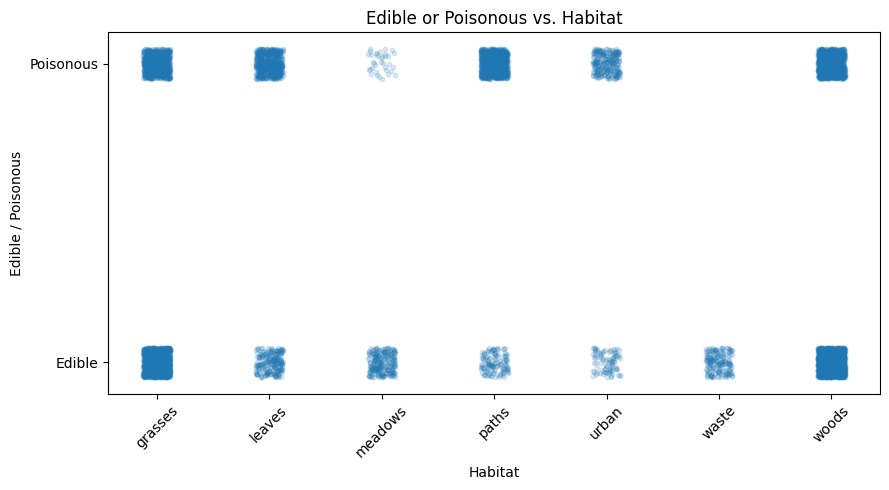

In [9]:
np.random.seed(0)

x = mushrooms["habitat"] + np.random.uniform(-0.12, 0.12, size=len(mushrooms))
y = mushrooms["edible_poisonous"] + np.random.uniform(-0.05, 0.05, size=len(mushrooms))

plt.figure(figsize=(9, 5))
plt.scatter(x, y, alpha=0.15, s=10)
plt.yticks([0, 1], ["Edible", "Poisonous"])
plt.xticks(range(len(habitat_labels)), list(habitat_labels.values()), rotation=45)
plt.title("Edible or Poisonous vs. Habitat")
plt.xlabel("Habitat")
plt.ylabel("Edible / Poisonous")
plt.tight_layout()
plt.show()

## Conclusion:

From the distributions and scatterplots, odor looks like the stronger predictor. The edible and poisonous mushrooms seem to separate more clearly by odor than by habitat.

Habitat still shows some pattern, but it does not look as strong or as clean as odor. Based on this quick exploration, I would expect odor to be more useful for predicting whether a mushroom is edible or poisonous.